In [1]:
from pyscf import gto, scf, cc
import numpy as np
from jax import numpy as jnp
from jax import vmap, jvp, jit
import jax
from functools import partial

a = 2 # 2aB
nH = 2
atoms = ""
for i in range(nH):
    atoms += f"H {i*a:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)


nfrozen = 0
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()[0]

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.14.0-37-generic', version='#37~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Nov 20 10:25:38 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Tue Feb 10 14:14:28 2026
PySCF version 2.11.0
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT HEAD (branch master) 3d1768f5e33b144b606c3d2c81c12ee54d794501

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 2
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr  

np.float64(-0.03964140088522034)

In [13]:
# example for PT2
options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 10,
            'n_walkers': 500,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'cisd/hf',
            'dt':0.005,
            'free_projection':False,
            'fp_abs': False,
            'group': False,
            'ad_mode':None,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted import prep
prep.prep_afqmc(mycc,options,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# If you import pyscf cc modules and use MPI for AFQMC in the same script, finalize MPI before calling the AFQMC driver.
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (1, 1)
# Number of basis functions: 2
# Number of Cholesky vectors: 3
#


In [7]:
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial
from ad_afqmc import config
from ad_afqmc.prop_unrestricted import sampling
import time

In [14]:
config.setup_jax()
MPI = config.setup_comm()
comm = MPI.COMM_WORLD
size = comm.Get_size()
rank = comm.Get_rank()

print = partial(print, flush=True)

ham_data, ham, prop, trial, wave_data, sampler, observable, options = (prep._prep_afqmc())

# Hostname: sharmagroup-rn
# System Type: Linux
# Machine Type: x86_64
# Processor: x86_64
# Hostname: sharmagroup-rn
# System Type: Linux
# Machine Type: x86_64
# Processor: x86_64
# Number of MPI ranks: 1
#
# norb: 2
# nelec: (1, 1)
#
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 10
# n_walkers: 500
# seed: 2
# walker_type: rhf
# trial: cisd/hf
# dt: 0.005
# free_projection: False
# fp_abs: False
# group: False
# use_gpu: False
# n_exp_terms: 6
# symmetry: False
# save_walkers: False
# ene0: 0.0
# n_batch: 1
# maxError: 0.001
#


In [15]:
trial.norb = trial._guide.norb
trial.nelec = trial._guide.nelec
trial.n_batch = trial._guide.n_batch

In [23]:
### initialize propagation
seed = options["seed"]
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(seed + rank)

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0
otg, eg, et = trial.calc_energy_mixed(
    prop_data['walkers'], ham_data, wave_data)
eg = jnp.array(jnp.sum(eg) / prop.n_walkers)
et = jnp.array(jnp.sum(et) / prop.n_walkers)
prop_data["e_estimate"] = eg
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

# comm.Barrier()
# if rank == 0:
#     print(f'# Propagating with {options["n_walkers"]*size} walkers')
#     print("# Equilibration sweeps:")
#     print("#   Iter \t Energy_G \t Energy_T \t Walltime")
#     print(f"  {0:5d} \t {eg:.6f} \t {et:.6f} \t ")
# comm.Barrier()

# sampler_eq = sampling.sampler_mixed(
#     n_prop_steps=50, n_ene_blocks=5, n_sr_blocks=10, n_chol = sampler.n_chol)

# for i,n in enumerate(range(1,options["n_eql"]+1)):
#     prop_data, (wt, wp, eg, et) =\
#         sampler_eq.propagate_phaseless(prop_data, ham_data, prop, trial, wave_data)

#     print(f"  {n:5d} \t {eg:.6f} \t {et:.6f}")

In [24]:
nsamples = 101

wp_sp = np.empty(nsamples)
eg_sp = np.empty(nsamples)
et_sp = np.empty(nsamples)

# comm.Barrier()
# if rank == 0:
print(f'# Propagating with {options["n_walkers"]*size} walkers')
print("# Equilibration sweeps:")
print("#   Iter \t Energy_G \t Energy_T \t Walltime")
print(f"  {0:5d} \t {eg:.6f} \t {et:.6f} \t ")
wp_sp[0] = sum(prop_data['weights'])
eg_sp[0] = eg
et_sp[0] = et

# comm.Barrier()

sampler_eq = sampling.sampler_mixed(
    n_prop_steps=50, n_ene_blocks=1, n_sr_blocks=5, n_chol = sampler.n_chol)

for n in range(1,nsamples):
    prop_data, (wt, wp, eg, et) =\
        sampler_eq.propagate_phaseless(prop_data, ham_data, prop, trial, wave_data)
    
    wp_sp[n] = wp
    eg_sp[n] = eg
    et_sp[n] = et

    print(f"  {n:5d} \t {eg:.6f} \t {et:.6f}")

# Propagating with 500 walkers
# Equilibration sweeps:
#   Iter 	 Energy_G 	 Energy_T 	 Walltime
      0 	 -1.096071 	 -1.056430 	 
      1 	 -1.096071 	 -1.077745
      2 	 -1.096071 	 -1.091531
      3 	 -1.096071 	 -1.091838
      4 	 -1.096071 	 -1.091731
      5 	 -1.096071 	 -1.091143
      6 	 -1.096071 	 -1.088100
      7 	 -1.096071 	 -1.093941
      8 	 -1.096071 	 -1.094356
      9 	 -1.096071 	 -1.094493
     10 	 -1.096071 	 -1.096411
     11 	 -1.096071 	 -1.088931
     12 	 -1.096071 	 -1.090542
     13 	 -1.096071 	 -1.098988
     14 	 -1.096071 	 -1.094568
     15 	 -1.096071 	 -1.093485
     16 	 -1.096071 	 -1.096343
     17 	 -1.096071 	 -1.095816
     18 	 -1.096071 	 -1.095473
     19 	 -1.096071 	 -1.095691
     20 	 -1.096071 	 -1.096519
     21 	 -1.096071 	 -1.091743
     22 	 -1.096071 	 -1.091958
     23 	 -1.096071 	 -1.096156
     24 	 -1.096071 	 -1.094801
     25 	 -1.096071 	 -1.093937
     26 	 -1.096071 	 -1.091864
     27 	 -1.096071 	 -1.093167
    

In [ ]:
# sampler = sampling.sampler_mixed(n_prop_steps=50, n_ene_blocks=3, n_sr_blocks=10, n_chol = sampler.n_chol)
# nsamples = 50
# wp_sp = np.empty(nsamples)
# eg_sp = np.empty(nsamples)
# et_sp = np.empty(nsamples)
# for i,n in enumerate(range(1,nsamples+1)):
#     prop_data, (wt, wp, eg, et)  =\
#         sampler.propagate_phaseless(prop_data, ham_data, prop, trial, wave_data)
#     wp_sp[i] = wp
#     eg_sp[i] = eg
#     et_sp[i] = et
#     print(f"  {n:5d} \t {eg:.6f} \t {et:.6f}")

      1 	 -1.096071 	 -1.092121
      2 	 -1.096071 	 -1.092691
      3 	 -1.096071 	 -1.095640
      4 	 -1.096071 	 -1.095556
      5 	 -1.096071 	 -1.095251
      6 	 -1.096071 	 -1.089583
      7 	 -1.096071 	 -1.093180
      8 	 -1.096071 	 -1.091068
      9 	 -1.096071 	 -1.094652
     10 	 -1.096071 	 -1.093845
     11 	 -1.096071 	 -1.096800
     12 	 -1.096071 	 -1.094720
     13 	 -1.096071 	 -1.092730
     14 	 -1.096071 	 -1.092143
     15 	 -1.096071 	 -1.095439
     16 	 -1.096071 	 -1.094491
     17 	 -1.096071 	 -1.092689
     18 	 -1.096071 	 -1.092140
     19 	 -1.096071 	 -1.093345
     20 	 -1.096071 	 -1.093555
     21 	 -1.096071 	 -1.091763
     22 	 -1.096071 	 -1.090735
     23 	 -1.096071 	 -1.094704
     24 	 -1.096071 	 -1.091457
     25 	 -1.096071 	 -1.090930
     26 	 -1.096071 	 -1.091080
     27 	 -1.096071 	 -1.089437
     28 	 -1.096071 	 -1.093163
     29 	 -1.096071 	 -1.095564
     30 	 -1.096071 	 -1.092783
     31 	 -1.096071 	 -1.093819
     32 

AFQMC/(Guide=CISD, Trial=CISD) average = -1.096071, 1sigma = 0.000000
AFQMC/(Guide=CISD, Trial=RHF)  average = -1.093359, 1sigma = 0.000246


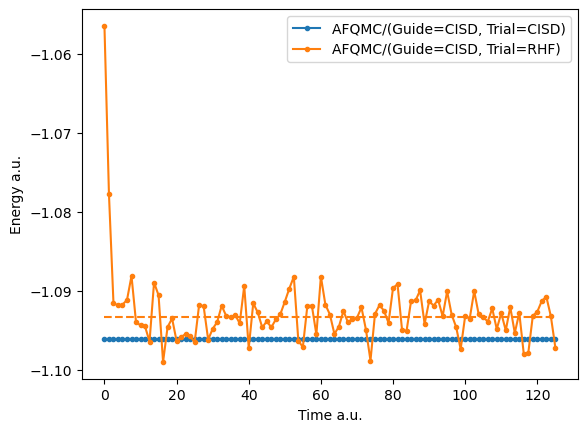

In [53]:
from matplotlib import pyplot as plt
neql = 10
eg_avg = eg_sp[neql:].mean()
eg_avg_std = np.std(eg_sp[neql:], ddof=1) / np.sqrt(len(eg_sp[neql:]))
et_avg = np.sum(wp_sp[neql:] * et_sp[neql:]) / np.sum(wp_sp[neql:])
et_avg_std = np.sqrt(np.sum(wp_sp[neql:]*(et_sp[neql:]-et_avg)**2/np.sum(wp_sp[neql:])))/np.sqrt(len(et_sp[neql:]))

print(f'AFQMC/(Guide=CISD, Trial=CISD) average = {eg_avg:.6f}, 1sigma = {eg_avg_std:.6f}')
print(f'AFQMC/(Guide=CISD, Trial=RHF)  average = {et_avg:.6f}, 1sigma = {et_avg_std:.6f}')

block_t = prop.dt * sampler_eq.n_prop_steps * sampler_eq.n_ene_blocks * sampler_eq.n_sr_blocks

plt.plot(block_t*np.arange(len(eg_sp)), eg_sp,'.-',label='AFQMC/(Guide=CISD, Trial=CISD)',color='C0')
plt.plot(block_t*np.arange(len(eg_sp)), [eg_avg]*len(eg_sp),'--',color='C0')
plt.plot(block_t*np.arange(len(et_sp)), et_sp,'.-',label='AFQMC/(Guide=CISD, Trial=RHF)',color='C1')
plt.plot(block_t*np.arange(len(et_sp)), [et_avg]*len(et_sp),'--',color='C1')

plt.xlabel('Time a.u.')
plt.ylabel('Energy a.u.')

plt.legend()
plt.show()

In [52]:
block_t

0.025

In [46]:
# example for PT2
options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 10,
            'n_walkers': 500,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'rhf',
            'dt':0.005,
            'free_projection':False,
            'ad_mode':None,
            'use_gpu': False,
            'group': False,
            'fp_abs': False,
            }

from ad_afqmc.prop_unrestricted import prep
prep.prep_afqmc(mycc,options,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# If you import pyscf cc modules and use MPI for AFQMC in the same script, finalize MPI before calling the AFQMC driver.
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (1, 1)
# Number of basis functions: 2
# Number of Cholesky vectors: 3
#


In [47]:
### initialize propagation
ham_data, ham, prop, trial, wave_data, sampler, observable, options = (prep._prep_afqmc())

seed = options["seed"]
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(seed + rank)

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0
ehf = trial.calc_energy(
    prop_data['walkers'], ham_data, wave_data)
ehf = jnp.array(jnp.sum(ehf) / prop.n_walkers)

prop_data["e_estimate"] = ehf
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

# comm.Barrier()
# if rank == 0:
#     print(f'# Propagating with {options["n_walkers"]*size} walkers')
#     print("# Equilibration sweeps:")
#     print("#   Iter \t Energy_HF \t Walltime")
#     print(f"  {0:5d} \t {ehf:.6f} \t ")
# comm.Barrier()

# sampler_eq = sampling.sampler(n_prop_steps=50, n_ene_blocks=5, n_sr_blocks=10, n_chol = sampler.n_chol)

# for i,n in enumerate(range(1,options["n_eql"]+1)):
#     prop_data, (wt, ehf) =\
#         sampler_eq.propagate_phaseless(ham, ham_data, prop, prop_data, trial, wave_data)

#     print(f"  {n:5d} \t {wt:.6f} \t {jnp.real(ehf):.6f}")

# Hostname: sharmagroup-rn
# System Type: Linux
# Machine Type: x86_64
# Processor: x86_64
# Number of MPI ranks: 1
#
# norb: 2
# nelec: (1, 1)
#
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 10
# n_walkers: 500
# seed: 2
# walker_type: rhf
# trial: rhf
# dt: 0.005
# free_projection: False
# use_gpu: False
# group: False
# fp_abs: False
# n_exp_terms: 6
# symmetry: False
# save_walkers: False
# ene0: 0.0
# n_batch: 1
# maxError: 0.001
#


In [48]:
print(f'# Propagating with {options["n_walkers"]*size} walkers')
print("# Equilibration sweeps:")
print("#   Iter \t Energy_HF \t Walltime")
print(f"  {0:5d} \t {ehf.real:.6f} \t ")

nsamples = 101

whf_sp = np.zeros(nsamples)
ehf_sp = np.zeros(nsamples)
whf_sp[0] = sum(prop_data['weights'])
ehf_sp[0] = ehf.real

sampler_eq = sampling.sampler(n_prop_steps=50, n_ene_blocks=1, n_sr_blocks=5, n_chol = sampler.n_chol)

for n in range(1,nsamples):
    prop_data, (wt, ehf) =\
        sampler_eq.propagate_phaseless(ham, ham_data, prop, prop_data, trial, wave_data)
    
    whf_sp[n] = wt
    ehf_sp[n] = ehf.real

    print(f"  {n:5d} \t {wt:.6f} \t {jnp.real(ehf):.6f}")

# Propagating with 500 walkers
# Equilibration sweeps:
#   Iter 	 Energy_HF 	 Walltime
      0 	 -1.056430 	 
      1 	 2502.416157 	 -1.078155
      2 	 2504.236612 	 -1.090491
      3 	 2504.574060 	 -1.091247
      4 	 2504.730899 	 -1.096708
      5 	 2504.786861 	 -1.097276
      6 	 2504.232043 	 -1.088808
      7 	 2504.330906 	 -1.091611
      8 	 2504.459551 	 -1.092607
      9 	 2504.107169 	 -1.090990
     10 	 2505.039489 	 -1.095933
     11 	 2504.220364 	 -1.092172
     12 	 2504.402478 	 -1.090339
     13 	 2504.582699 	 -1.094012
     14 	 2504.340626 	 -1.092353
     15 	 2504.475329 	 -1.096498
     16 	 2505.685643 	 -1.108734
     17 	 2505.319477 	 -1.104444
     18 	 2504.617435 	 -1.095725
     19 	 2505.583909 	 -1.102293
     20 	 2505.286436 	 -1.097701
     21 	 2504.017526 	 -1.087624
     22 	 2503.542917 	 -1.090291
     23 	 2504.743221 	 -1.097125
     24 	 2505.043227 	 -1.097050
     25 	 2504.619812 	 -1.095133
     26 	 2504.455311 	 -1.093700
     2

AFQMC/(Guide=CISD, Trial=CISD) average = -1.096071, 1sigma = 0.000000
AFQMC/(Guide=CISD, Trial=RHF)  average = -1.093359, 1sigma = 0.000246
AFQMC/(Guide=RHF, Trial=RHF)  average = -1.093251, 1sigma = 0.000448


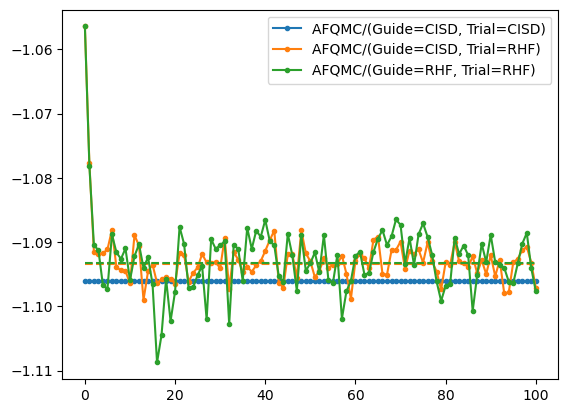

In [49]:
from matplotlib import pyplot as plt
neql = 10
eg_avg = eg_sp[neql:].mean()
eg_avg_std = np.std(eg_sp[neql:], ddof=1) / np.sqrt(len(eg_sp[neql:]))
et_avg = np.sum(wp_sp[neql:] * et_sp[neql:]) / np.sum(wp_sp[neql:])
et_avg_std = np.sqrt(np.sum(wp_sp[neql:]*(et_sp[neql:]-et_avg)**2/np.sum(wp_sp[neql:])))/np.sqrt(len(et_sp[neql:]))
ehf_avg = np.sum(whf_sp[neql:] * ehf_sp[neql:]) / np.sum(whf_sp[neql:])
ehf_avg_std = np.sqrt(np.sum(whf_sp[neql:]*(ehf_sp[neql:]-ehf_avg)**2/np.sum(whf_sp[neql:])))/np.sqrt(len(ehf_sp[neql:]))

print(f'AFQMC/(Guide=CISD, Trial=CISD) average = {eg_avg:.6f}, 1sigma = {eg_avg_std:.6f}')
print(f'AFQMC/(Guide=CISD, Trial=RHF)  average = {et_avg:.6f}, 1sigma = {et_avg_std:.6f}')
print(f'AFQMC/(Guide=RHF, Trial=RHF)  average = {ehf_avg:.6f}, 1sigma = {ehf_avg_std:.6f}')

plt.plot(eg_sp,'.-',label='AFQMC/(Guide=CISD, Trial=CISD)',color='C0')
plt.plot([eg_avg]*len(eg_sp),'--',color='C0')
plt.plot(et_sp,'.-',label='AFQMC/(Guide=CISD, Trial=RHF)',color='C1')
plt.plot([et_avg]*len(et_sp),'--',color='C1')
plt.plot(ehf_sp,'.-',label='AFQMC/(Guide=RHF, Trial=RHF)',color='C2')
plt.plot([ehf_avg]*len(ehf_sp),'--',color='C2')

plt.legend()
plt.show()

In [ ]:
# sampler = sampling.sampler(n_prop_steps=50, n_ene_blocks=3, n_sr_blocks=10, n_chol = sampler.n_chol)
# nsamples = 50
# wt_sp = np.empty(nsamples)
# ehf_sp = np.empty(nsamples)
# for i,n in enumerate(range(1,nsamples+1)):
#     prop_data, (wt, ehf)  =\
#         sampler.propagate_phaseless(ham, ham_data, prop, prop_data, trial, wave_data)
#     wt_sp[i] = wt
#     ehf_sp[i] = jnp.real(ehf)
#     print(f"  {n:5d} \t {wt:.6f} \t {jnp.real(ehf):.6f}")

      1 	 9009.413778 	 -1.147866
      2 	 9008.250468 	 -1.145261
      3 	 9008.502745 	 -1.145322
      4 	 9009.164349 	 -1.146153
      5 	 9008.813530 	 -1.146346
      6 	 9008.208751 	 -1.144784
      7 	 9008.828922 	 -1.145748
      8 	 9008.501992 	 -1.146172
      9 	 9008.386624 	 -1.145222
     10 	 9008.588018 	 -1.145150
     11 	 9014.470581 	 -1.159874
     12 	 9010.401222 	 -1.147510
     13 	 9008.678679 	 -1.145168
     14 	 9008.666835 	 -1.145455
     15 	 9008.743751 	 -1.145367
     16 	 9009.713490 	 -1.146360
     17 	 9008.693906 	 -1.144843
     18 	 9008.609163 	 -1.145939
     19 	 9008.076903 	 -1.144388
     20 	 9008.608008 	 -1.146153
     21 	 9009.031416 	 -1.146393
     22 	 9009.226826 	 -1.146134
     23 	 9008.478635 	 -1.145429
     24 	 9007.742986 	 -1.144732
     25 	 9008.076038 	 -1.145375
     26 	 9008.658744 	 -1.146120
     27 	 9008.991886 	 -1.145772
     28 	 9009.229321 	 -1.146155
     29 	 9008.302145 	 -1.144882
     30 	 9009

AFQMC/Guide=CISD average = -1.1459398096416462, std = 1.0369264561865222e-09
AFQMC/Trial=RHF  average = -1.14572000030799, std = 0.00011178909873585755
AFQMC/Pure_RHF  average = -1.1461845323090432, std = 0.00031602651951957364


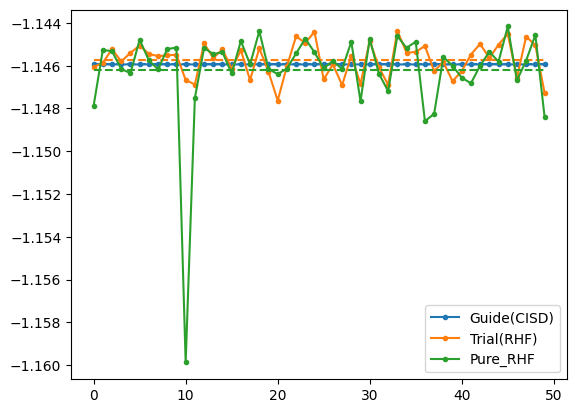

In [13]:
from matplotlib import pyplot as plt
eg_avg = eg_sp.mean()
eg_avg_std = np.std(eg_sp, ddof=1) / np.sqrt(len(eg_sp))
et_avg = np.sum(wp_sp * et_sp) / np.sum(wp_sp)
et_avg_std = np.std(et_sp, ddof=1) / np.sqrt(len(et_sp))
ehf_avg = ehf_sp.mean()
ehf_avg_std = np.std(ehf_sp, ddof=1) / np.sqrt(len(ehf_sp))

print(f'AFQMC/Guide=CISD average = {eg_avg}, std = {eg_avg_std}')
print(f'AFQMC/Trial=RHF  average = {et_avg}, std = {et_avg_std}')
print(f'AFQMC/Pure_RHF  average = {ehf_avg}, std = {ehf_avg_std}')

plt.plot(eg_sp,'.-',label='Guide(CISD)',color='C0')
plt.plot([eg_avg]*len(eg_sp),'--',color='C0')
plt.plot(et_sp,'.-',label='Trial(RHF)',color='C1')
plt.plot([et_avg]*len(et_sp),'--',color='C1')
plt.plot(ehf_sp,'.-',label='Pure_RHF',color='C2')
plt.plot([ehf_avg]*len(ehf_sp),'--',color='C2')

plt.legend()
plt.show()